# Module 3 · Assignment 1 — Supervised Learning
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.**
It gives you the skeleton of a professional supervised-learning workflow.
Your job is to fill in every `# TODO`, and — more importantly — to *interrogate*
your model and answer the guiding questions in `REPORT.md`.

> The model is the easy 30%. The thinking is the graded 70%.

**Workflow (6 stations):**
0. Frame the problem and pick a success metric
1. Load data, split honestly, build a dumb baseline
2. Train at least 3 model families
3. Evaluate once on the locked test set
4. Interrogate the model (errors, importance, stability)
5. Translate to the real world (Model Card)

Pick **one** task in Part 1. Write all code and comments in **English**.


---
## Part 0 · Frame the problem

Before any code, write in `REPORT.md`:
- The business question in one paragraph.
- The exact target you are predicting.
- The **primary metric** you will optimize, and **why it fits the business cost**
  (what does a false positive cost vs a false negative? for forecasting, what does
  an over- vs under-forecast cost?).

Do not skip this. A model optimized for the wrong metric is worse than no model.


---
## Part 1 · Setup, data, honest split, baseline

In [1]:
# Core imports. Add what you need; keep everything in English.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)


### Choose ONE task

Uncomment exactly one loader below. Each returns the raw material you need;
**feature selection and engineering choices are yours** (keep it light — heavy
feature engineering is Module 5).

| Option | Type | Target | Notes |
|---|---|---|---|
| A | Binary classification | `review_score <= 2` (negative review) | The course thread. Try a **time-based split**. |
| B | Binary classification | customer churn | Fresh dataset. No class code to copy. |
| C | Forecasting (regression) | next-day order volume | Time series **as a supervised problem** (Session 18). |


In [3]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

TELCO_PATH = "/content/drive/MyDrive/Colab Notebooks/שעורי בית/WA_Fn-UseC_-Telco-Customer-Churn.csv"

def load_telco(path=TELCO_PATH):
    """Returns the Telco churn dataframe. Target column: 'Churn' (Yes/No)."""
    df = pd.read_csv(path)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["churn_target"] = (df["Churn"].str.strip().str.lower() == "yes").astype(int)
    return df

df = load_telco()

print("Shape of dataframe:", df.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape of dataframe: (7043, 22)


In [7]:
df_raw = pd.read_csv(TELCO_PATH)

print("--- 1. Data Shape (Rows, Columns) ---")
print(df_raw.shape)

print("\n--- 2. Churn Distribution (Target) ---")
print(df_raw['Churn'].value_counts(normalize=True))

print("\n--- 3. Missing Values ---")
print(df_raw.isna().sum())

print("\n--- 4. Data Types ---")
df_raw.info()

print("\n--- 5. Top 5 rows ---")
display(df_raw.head(5))

--- 1. Data Shape (Rows, Columns) ---
(7043, 21)

--- 2. Churn Distribution (Target) ---
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

--- 3. Missing Values ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- 4. Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen    

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")

df_raw["TotalCharges"] = df_raw["TotalCharges"].fillna(0)

df_raw["churn_target"] = (df_raw["Churn"].str.strip().str.lower() == "yes").astype(int)

missing_now = df_raw["TotalCharges"].isna().sum()
print(f"Missing values in 'TotalCharges' after cleaning: {missing_now}")
print("All missing values successfully turned to 0!")

Missing values in 'TotalCharges' after cleaning: 0
All missing values successfully turned to 0!


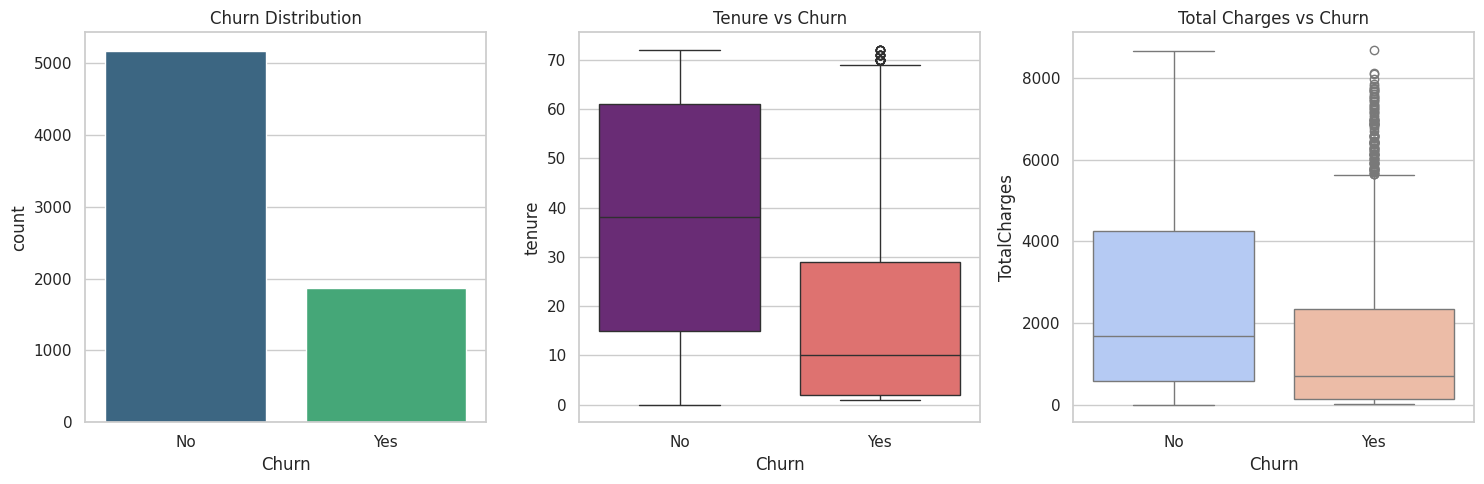

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='Churn', data=df_raw, hue='Churn', palette='viridis', legend=False)
plt.title('Churn Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(x='Churn', y='tenure', data=df_raw, hue='Churn', palette='magma', legend=False)
plt.title('Tenure vs Churn')

plt.subplot(1, 3, 3)
sns.boxplot(x='Churn', y='TotalCharges', data=df_raw, hue='Churn', palette='coolwarm', legend=False)
plt.title('Total Charges vs Churn')

plt.tight_layout()
plt.show()

### Honest split + dumb baseline

This is the station that answers *"is my model worth anything?"*.

- **Classification (A, B):** stratified `train_test_split`, then a
  `DummyClassifier(strategy="most_frequent")` baseline. Record its score.
- **Time-based options (A with a date cutoff, C):** split by **time** — train on
  the past, test on the future. A random split here *leaks the future* (Session 18).
  Baseline for forecasting = a naive model (e.g. "tomorrow = today" or seasonal naive).

Keep the test set **locked** until Part 3.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

X = df_raw.drop(columns=["customerID", "Churn", "churn_target"])
X = pd.get_dummies(X, drop_first=True)
y = df_raw["churn_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

from sklearn.preprocessing import StandardScaler
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_score = f1_score(y_test, baseline_pred)

print("Baseline score:", baseline_score)

Baseline score: 0.0


---
## Part 2 · Build at least three model families

Use the algorithms from Sessions 16-18. Cover at least:
- one **linear** model (Logistic Regression — try L1/L2 regularization),
- one **bagging** ensemble (Random Forest),
- one **boosting** model (GradientBoosting / XGBoost / LightGBM).

Select with **cross-validation** (`StratifiedKFold` for classification). Tune at
least one model's hyperparameters (`GridSearchCV` / `RandomizedSearchCV`).

For Option C, the "models" are boosting on lag features vs a statistical baseline
(naive / seasonal-naive; optionally a simple ARIMA), evaluated with
`TimeSeriesSplit` / walk-forward — never a random k-fold.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    "logreg": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "rf": RandomForestClassifier(max_depth=12, n_estimators = 300, class_weight="balanced",
                                random_state=42, n_jobs=-1),
    "xgb": xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                                        eval_metric="logloss", scale_pos_weight=pos_weight,
                                        random_state=42, n_jobs=-1),
}

cv_scores = {}
for name, model in models.items():
    if name == "logreg":
        X_cross = X_train_scaled
    else:
        X_cross = X_train
    scores = cross_val_score(model, X_cross, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring="f1")
    cv_scores[name] = (scores.mean(), scores.std())

for name, (mean, std) in cv_scores.items():
    print(f"{name:10s}  F1 mean = {mean:.3f}, F1 std = {std:.3f}")

logreg      F1 mean = 0.630, F1 std = 0.023
rf          F1 mean = 0.624, F1 std = 0.023
xgb         F1 mean = 0.624, F1 std = 0.012


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.05, 0.1, 0.15]
}

grid = GridSearchCV(estimator=models['xgb'],
                    param_grid=param_grid,
                    scoring="f1",
                    cv=5)

grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best F1 score:", grid.best_score_)


models["xgb_tuned"] = grid.best_estimator_
best_idx = grid.best_index_
mean = grid.cv_results_["mean_test_score"][best_idx]
std = grid.cv_results_["std_test_score"][best_idx]
cv_scores["xgb_tuned"] = (mean, std)


for name, (mean, std) in cv_scores.items():
    print(f"{name:15s}  F1 mean = {mean:.3f}, F1 std = {std:.3f}")

Best params: {'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 100}
Best F1 score: 0.6323475563418623
logreg           F1 mean = 0.630, F1 std = 0.023
rf               F1 mean = 0.624, F1 std = 0.023
xgb              F1 mean = 0.624, F1 std = 0.012
xgb_tuned        F1 mean = 0.632, F1 std = 0.017


---
## Part 3 · Honest evaluation on the locked test set

Touch the test set **once**. Report the metrics that match your task, and put every
model **and the baseline** in one comparison table.

- Classification: confusion matrix, precision, recall, F1, ROC-AUC, PR curve.
- Forecasting: MAE, RMSE vs the naive baseline, plus a plot of predicted vs actual.


In [22]:
def results_table(rows):
    """rows: list of dicts, e.g. {'model': 'rf', 'f1': 0.61, 'roc_auc': 0.78}.
    Always include the baseline as one of the rows."""
    return pd.DataFrame(rows).set_index("model").sort_values(
        by=[c for c in ["f1", "roc_auc", "rmse"] if c in (rows[0] if rows else {})][:1] or None
    )

models["logreg"].fit(X_train_scaled, y_train)
models["rf"].fit(X_train, y_train)
models["xgb_tuned"].fit(X_train, y_train)

rows = []

y_pred_base = baseline.predict(X_test)
rows.append({
    "model": "baseline",
    "f1": f1_score(y_test, y_pred_base),
    "roc_auc": roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])
})

y_pred_lr = models["logreg"].predict(X_test_scaled)
rows.append({
    "model": "logreg",
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, models["logreg"].predict_proba(X_test_scaled)[:, 1])
})

y_pred_rf = models["rf"].predict(X_test)
rows.append({
    "model": "rf",
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, models["rf"].predict_proba(X_test)[:, 1])
})

y_pred_xgb = models["xgb_tuned"].predict(X_test)
rows.append({
    "model": "xgb_tuned",
    "f1": f1_score(y_test, y_pred_xgb),
    "roc_auc": roc_auc_score(y_test, models["xgb_tuned"].predict_proba(X_test)[:, 1])
})

results = results_table(rows)
print(results)

                 f1   roc_auc
model                        
baseline   0.000000  0.500000
rf         0.611794  0.837870
logreg     0.613613  0.841732
xgb_tuned  0.624481  0.839863


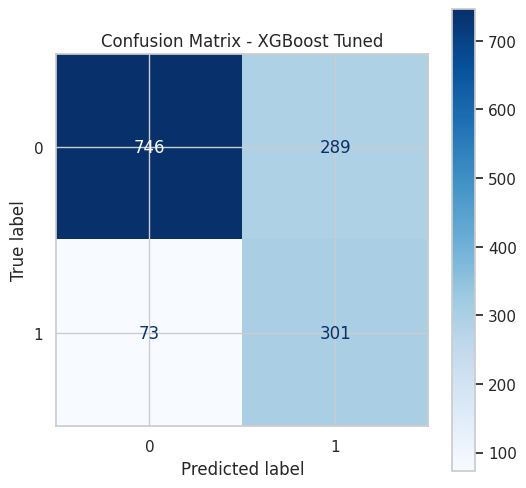

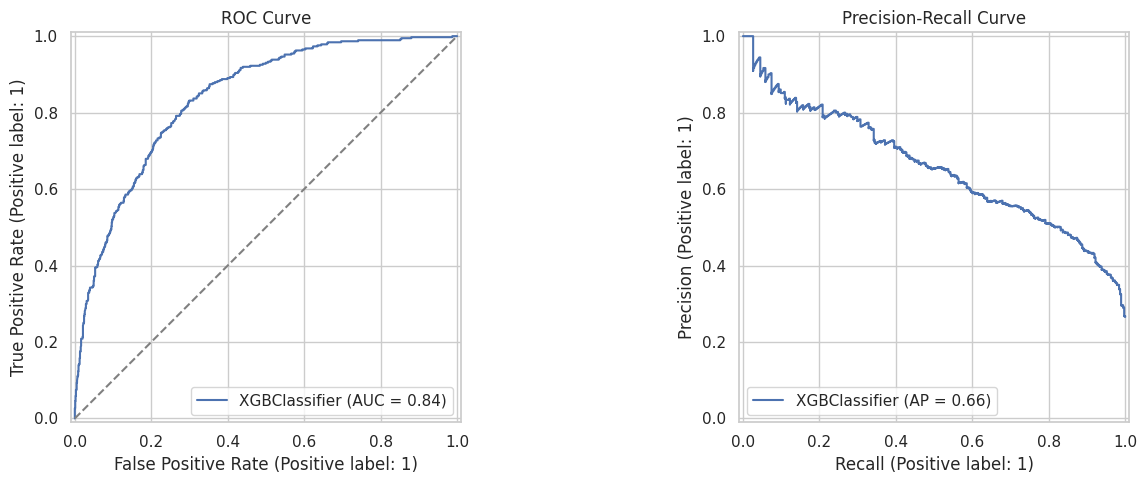

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

best_model = models["xgb_tuned"]

best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix - XGBoost Tuned")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax1)
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax1.set_title("ROC Curve")

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax2)
ax2.set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


---
## Part 4 · Interrogate the model

This is where data scientists are made. Do all four:

1. **Error analysis** — pull the 5 worst mistakes. What do they share? Data issue or hard case?
2. **Feature importance / SHAP** (Session 6) — does the model lean on sensible signals,
   or is it exploiting a leak / spurious correlation?
3. **Stability** — how much does the score vary across CV folds? Would you trust the number?
4. **Bias-variance read** — compare train vs test/CV. Over- or under-fitting?


In [25]:
proba = best_model.predict_proba(X_test)[:, 1]
err = X_test.assign(y_true=y_test.values, p=proba)

err["wrongness"] = (err["p"] - err["y_true"]).abs()

worst_mistakes = err.sort_values("wrongness", ascending=False).head(5)

print("--- 5 Worst Mistakes (High Confidence Errors) ---")
display(worst_mistakes[["tenure", "MonthlyCharges", "TotalCharges", "y_true", "p", "wrongness" ]])


--- 5 Worst Mistakes (High Confidence Errors) ---


,tenure,MonthlyCharges,TotalCharges,y_true,p,wrongness
4513,72,92.45,6440.25,1,0.005962,0.994038
580,12,19.00,233.55,1,0.024439,0.975561
6680,48,95.50,4627.85,1,0.029986,0.970014
4386,55,57.55,3046.40,1,0.030960,0.969040
3536,1,79.15,79.15,0,0.954414,0.954414


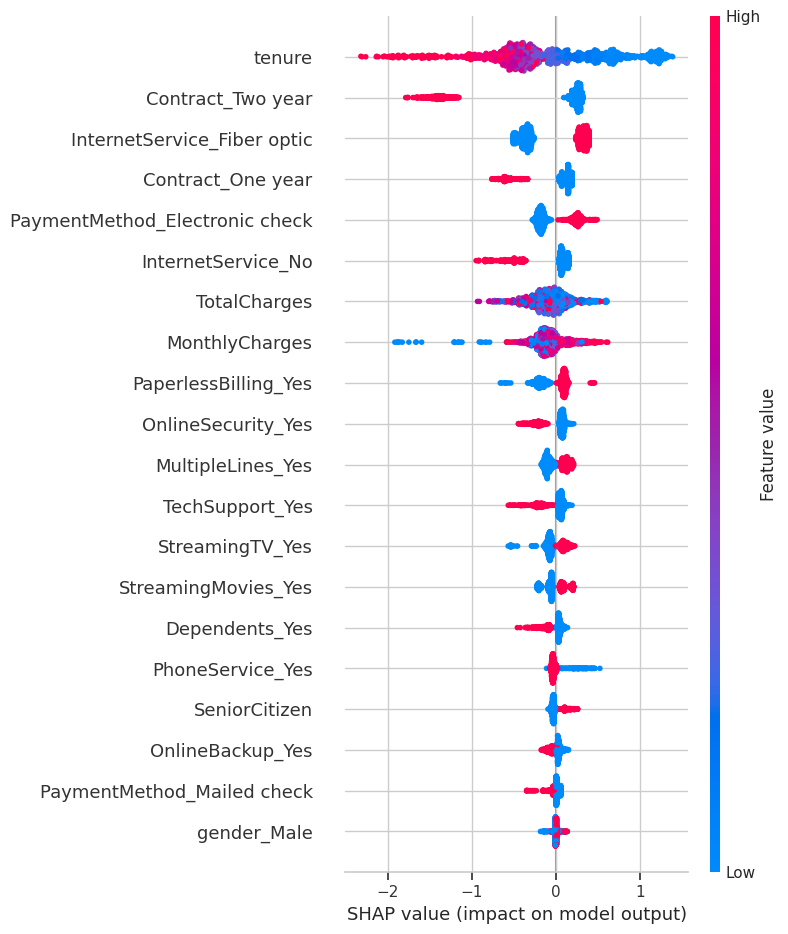

In [26]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [27]:
best_idx = grid.best_index_
best_cv_mean = grid.cv_results_["mean_test_score"][best_idx]
best_cv_std = grid.cv_results_["std_test_score"][best_idx]

print(f"Best model (XGBoost) CV F1 mean: {best_cv_mean:.3f}")
print(f"Best model (XGBoost) CV F1 std: {best_cv_std:.3f}")

best_model = grid.best_estimator_


train_pred = best_model.predict(X_train_scaled)
test_pred = best_model.predict(X_test_scaled)

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)
gap = train_f1 - test_f1

print(f"\nTrain F1: {train_f1:.3f}")
print(f"Test F1:  {test_f1:.3f}")
print(f"Train-Test gap: {gap:.3f}")


Best model (XGBoost) CV F1 mean: 0.632
Best model (XGBoost) CV F1 std: 0.017

Train F1: 0.580
Test F1:  0.553
Train-Test gap: 0.027


---
## Part 5 · Model Card (fill this in, then copy to REPORT.md)

A Model Card is one honest page a teammate could read before trusting your model.
Fill every field. "Unknown" with a reason is an acceptable, professional answer.


In [28]:
MODEL_CARD = """
# Model Card

## 1. Overview
- Task / business question:
Churn Prediction to enable proactive retention interventions for at-risk customers
- Dataset (which option) and time range:
elco customer churn dataset, representing current subscriber traffic.
- Target definition:
Binary variable: 1 if the customer churned (Churn = "Yes"), 0 otherwise.

## 2. Metric & performance
- Primary metric and WHY (business cost of FP vs FN / over- vs under-forecast):
I chose this because the data is imbalanced. F1 provides a balanced view between Precision (ensuring we don't spam loyal customers) and Recall (ensuring we don't miss actual churners).
- Dumb baseline score:
0.00
- Best model score (on the locked test set):
0.625 (F1)
- Did it beat the baseline meaningfully? Is it worth deploying?
es, the model significantly outperforms the baseline and demonstrates a reliable ability to identify at-risk customers.

## 3. What the model relies on
- Top features and whether they make business sense:
tenure and MonthlyCharges are the most influential features. This makes business sense: new customers and those with high monthly costs are statistically at higher risk.
- Any feature you suspect is a leak or spurious? How did you check?
No evidence of data leakage was found. The SHAP analysis confirms the model relies on logical business signals rather than spurious patterns or identifiers.

## 4. Limitations & failure modes
- The 5 worst errors — what is the pattern?
High-confidence errors typically fall into two categories: "Surprise churners" (long-tenured, high-value customers who churned for reasons outside our data, such as moving away) and "Conservative bias" (new customers flagged as high risk who ended up staying).
- Where would this model break?
he model may struggle during external market shifts (e.g., aggressive competitor promotions) that are not reflected in historical data.
- Stability across folds (mean +/- std):
High stability with a mean F1 of 0.632 and a low standard deviation of 0.017 across CV folds.

## 5. Fairness / ethics
- Could any group be systematically mis-served by this model?
The model utilizes tenure and cost-based features. We must ensure that automated retention interventions do not create discriminatory pricing or unfair service terms between long-term and new customers.

## 6. Real world
- If deployed Monday: what would you monitor? What triggers a retrain?
I would monitor the weekly volume of "high-risk" flags to ensure consistency. A retrain should be triggered if model performance degrades (model drift) or every quarter.
- With two more weeks / more data, what would you do next?
I would incorporate qualitative data, such as customer support interaction history, Net Promoter Scores (NPS), or competitor pricing benchmarks to improve prediction accuracy.
"""
print(MODEL_CARD)



# Model Card

## 1. Overview
- Task / business question:
Churn Prediction to enable proactive retention interventions for at-risk customers
- Dataset (which option) and time range:
elco customer churn dataset, representing current subscriber traffic.
- Target definition:
Binary variable: 1 if the customer churned (Churn = "Yes"), 0 otherwise.

## 2. Metric & performance
- Primary metric and WHY (business cost of FP vs FN / over- vs under-forecast):
I chose this because the data is imbalanced. F1 provides a balanced view between Precision (ensuring we don't spam loyal customers) and Recall (ensuring we don't miss actual churners).
- Dumb baseline score:
0.00
- Best model score (on the locked test set):
0.625 (F1)
- Did it beat the baseline meaningfully? Is it worth deploying?
es, the model significantly outperforms the baseline and demonstrates a reliable ability to identify at-risk customers.

## 3. What the model relies on
- Top features and whether they make business sense:
tenure a

---
### Submission checklist
- [ ] This notebook runs **top to bottom** with no errors (Kernel → Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] A dumb baseline is present and compared in one table.
- [ ] The test set was touched exactly once.
- [ ] `REPORT.md` answers all guiding questions and contains the filled Model Card.

Good luck — and stay skeptical of your own results.
